DuckDB SQL 计算基础指标 yellow_taxi_basic_metrics

成功读取清洗后数据，共 178,170,956 条记录
=== 整体运营指标 ===
 total_trips  avg_distance_miles  avg_fare  avg_tip  avg_total  avg_duration_minutes  median_tip  tip_rate
   178170956                3.43     17.55     3.26      25.95                 17.41        2.56      0.78

=== 各时段指标(前5行预览)===
   hour  trip_count  avg_distance   avg_fare   avg_tip  avg_total  \
0     0     4653765      4.077113  18.473875  3.382231  27.120955   
1     1     3036326      3.617427  16.704710  3.043676  24.759528   
2     2     1973422      3.314304  15.543847  2.812946  23.255775   
3     3     1271341      3.570137  16.375968  2.839380  24.221922   
4     4      828570      5.071628  21.640905  3.412814  30.697068   
5     5      990194      6.324399  25.330056  3.807356  35.103812   
6     6     2435835      4.927730  20.526010  3.212829  28.497353   
7     7     4775378      3.749937  17.476804  3.040818  25.013948   
8     8     6634274      3.244161  16.605005  3.005207  24.029424   
9     9     7673535      3.12825

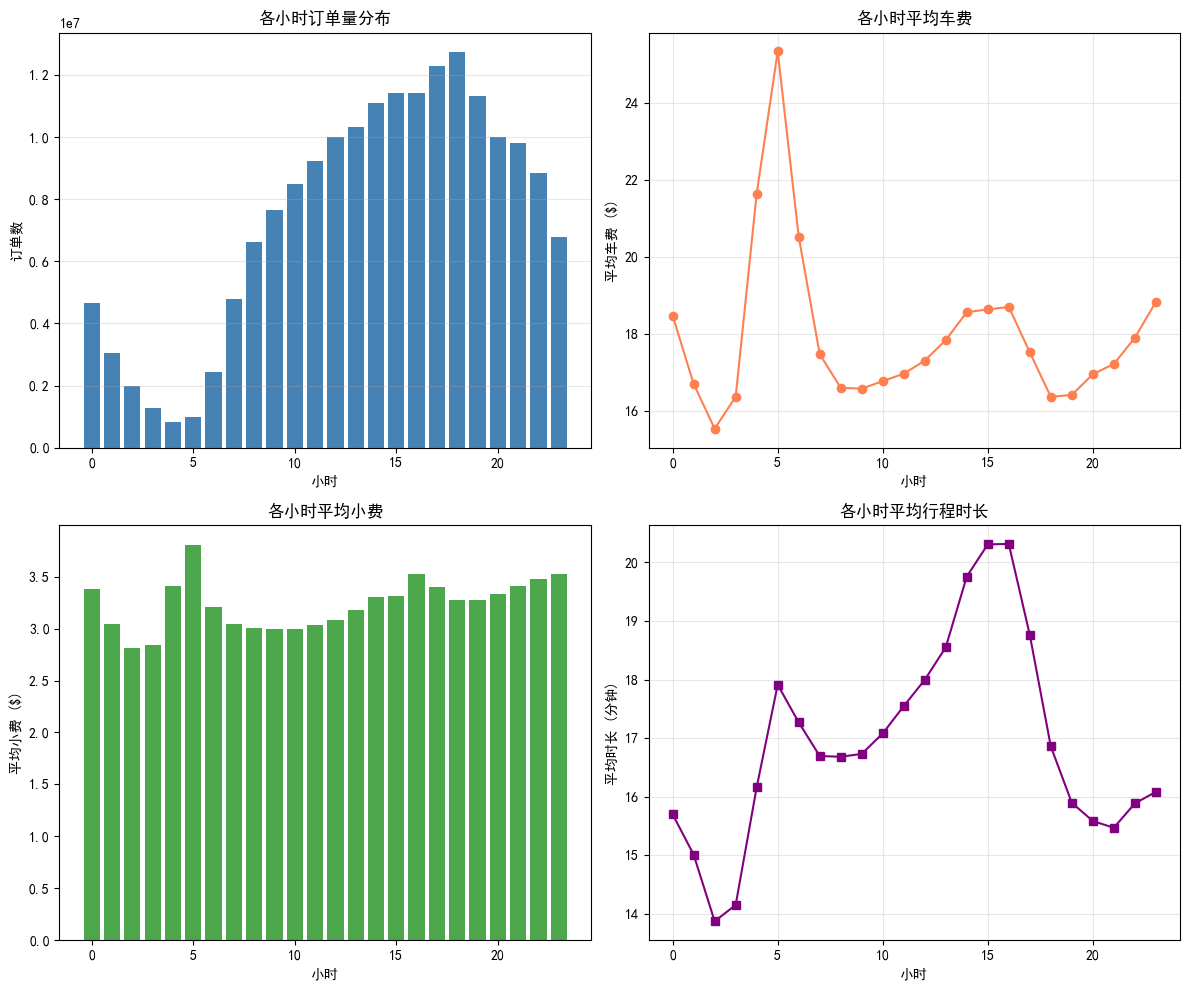


=== 月度趋势(前5行预览)===
       month  trip_count   avg_fare   avg_tip  avg_total  total_revenue
0 2021-01-01     1214528  10.981483  1.963932  16.478284   2.001334e+07
1 2021-02-01     1218946  11.066761  2.010168  16.622411   2.026182e+07
2 2021-03-01     1720009  11.152216  2.038729  16.792834   2.888383e+07
3 2021-04-01     1955468  11.710075  2.148726  17.560936   3.433985e+07
4 2021-05-01     2281293  12.208330  2.257582  18.250830   4.163549e+07


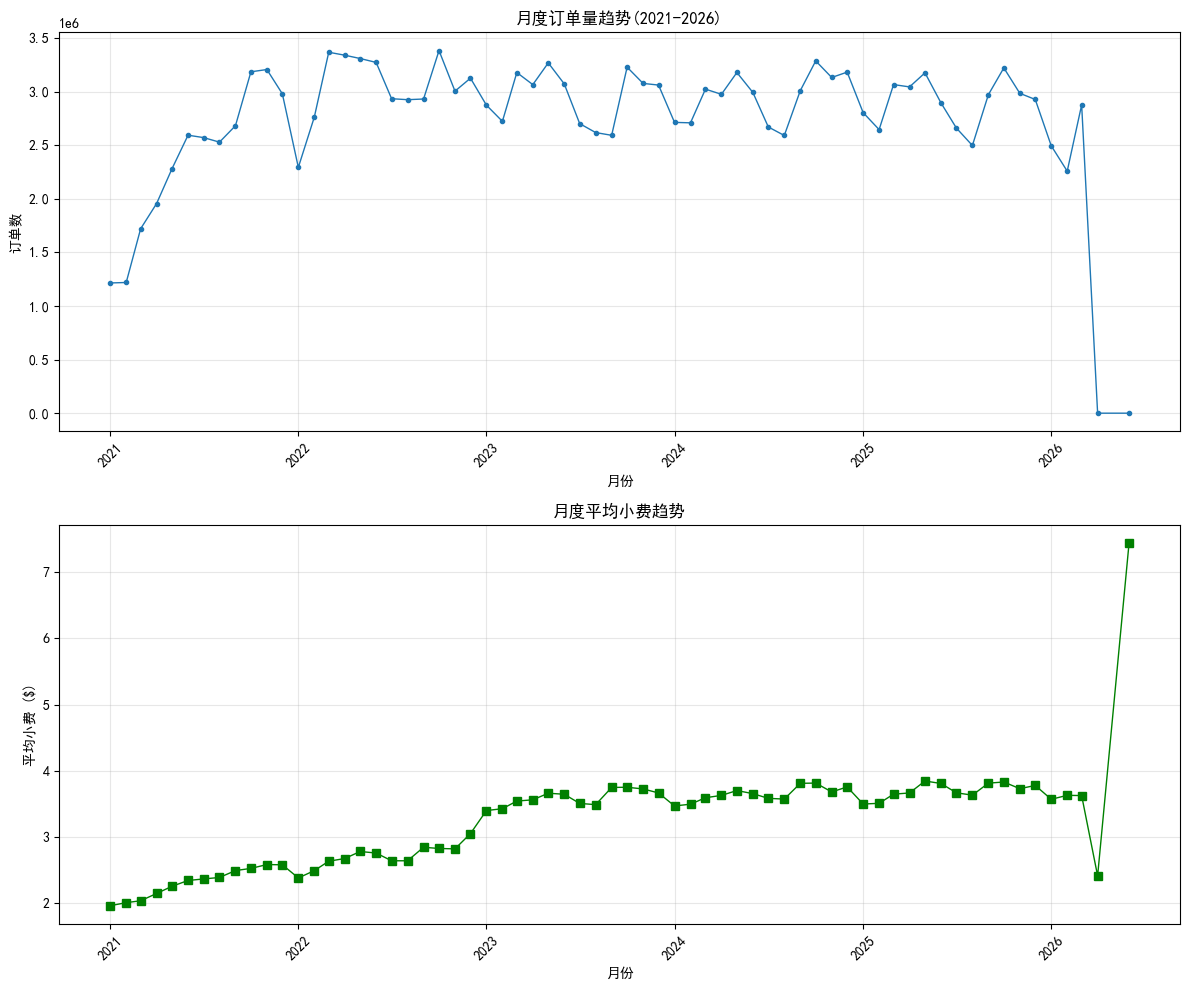


=== 支付方式分布 ===
   payment_type      count    percentage  avg_tip_per_payment  \
0             1  146416958  8.217779e-01             3.964227   
1             2   29927192  1.679690e-01             0.000266   
2             4    1251322  7.023154e-03             0.011360   
3             3     575481  3.229937e-03             0.004733   
4             5          3  1.683776e-08             0.000000   

   avg_total_per_payment  
0              26.811114  
1              21.672789  
2              28.032918  
3              23.307927  
4              30.530000  


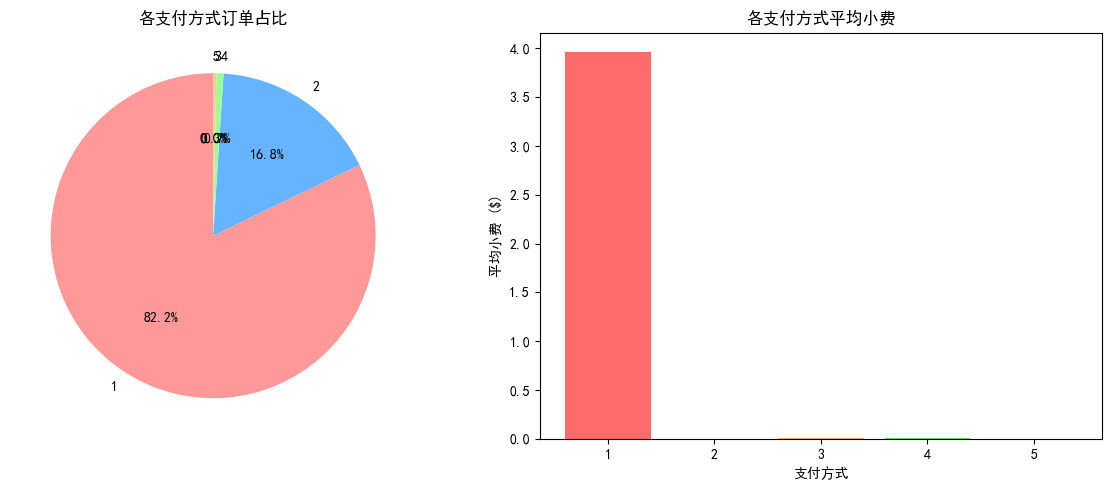


=== 行程距离分布 ===
  distance_group  trip_count   avg_fare    avg_tip
0          0-1英里    37984047   6.954432   1.686030
1          1-2英里    59929299  10.609991   2.271306
2          2-5英里    50031401  17.067114   3.194302
3         5-10英里    15396211  31.483659   5.396244
4        10-20英里    12949050  56.530229   8.971580
5         20英里以上     1880948  83.434601  11.283882


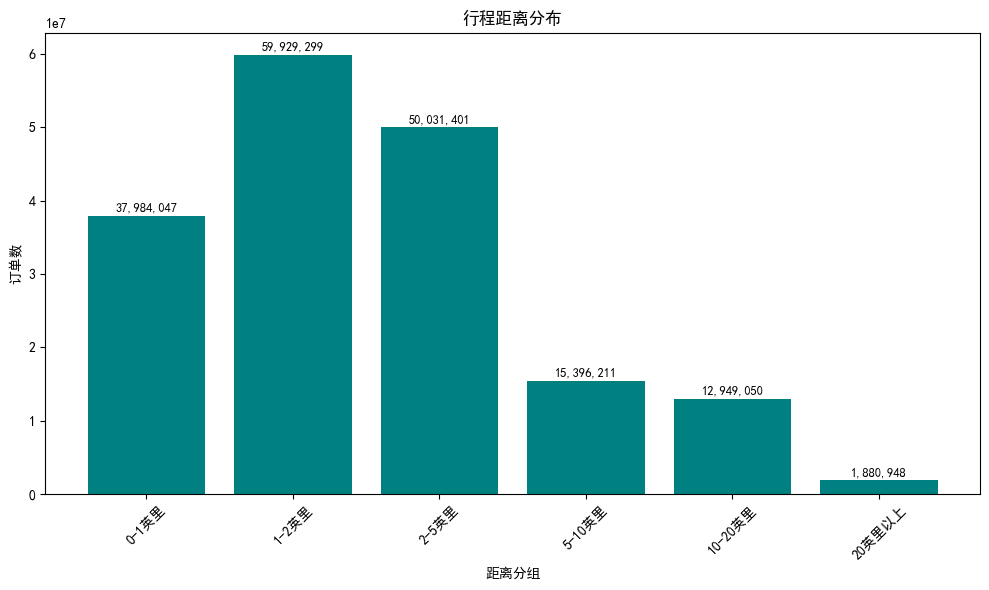


=== 异常值统计 ===
   outlier_type   count
0  极短行程(距离<0.1)   14299
1   极长行程(距离>50)   23964
2  极高小费(小费>100)     978
3  极长时长(>180分钟)  182393

统计结果已保存到 D:/yellow_taxi/yellow_taxi_basic_metrics/ 目录


In [ ]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

conn = duckdb.connect()
cleaned_data_path = "D:/yellow_taxi/yellow_taxi_data_cleaned/**/*.parquet"

# 1. 验证是否能读取
try:
    test_count = conn.execute(f"SELECT COUNT(*) FROM read_parquet('{cleaned_data_path}')").fetchone()[0]
    print(f"成功读取清洗后数据，共 {test_count:,} 条记录")
except Exception as e:
    print(f"读取失败：{e}")
    print("请确认路径是否正确")

# 2. 整体统计指标
overall_stats = conn.execute(f"""
SELECT 
    COUNT(*) AS total_trips,
    AVG(trip_distance) AS avg_distance_miles,
    AVG(fare_amount) AS avg_fare,
    AVG(tip_amount) AS avg_tip,
    AVG(total_amount) AS avg_total,
    AVG(trip_duration_minutes) AS avg_duration_minutes,
    -- 小费中位数(更稳健)
    MEDIAN(tip_amount) AS median_tip,
    -- 小费比例(支付小费的订单占比,tip_amount > 0)
    SUM(CASE WHEN tip_amount > 0 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS tip_rate
FROM read_parquet('{cleaned_data_path}')
""").fetchdf()
print("=== 整体运营指标 ===")
print(overall_stats.round(2).to_string(index=False))

# 3. 按小时聚合 进行时段分析
hourly_stats = conn.execute(f"""
SELECT 
    EXTRACT(HOUR FROM tpep_pickup_datetime) AS hour,
    COUNT(*) AS trip_count,
    AVG(trip_distance) AS avg_distance,
    AVG(fare_amount) AS avg_fare,
    AVG(tip_amount) AS avg_tip,
    AVG(total_amount) AS avg_total,
    AVG(trip_duration_minutes) AS avg_duration
FROM read_parquet('{cleaned_data_path}')
GROUP BY hour
ORDER BY hour
""").fetchdf()

print("\n=== 各时段指标(前5行预览)===")
print(hourly_stats.head(10))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].bar(hourly_stats['hour'], hourly_stats['trip_count'], color='steelblue')
axes[0, 0].set_title('各小时订单量分布')
axes[0, 0].set_xlabel('小时')
axes[0, 0].set_ylabel('订单数')
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].plot(hourly_stats['hour'], hourly_stats['avg_fare'], marker='o', color='coral')
axes[0, 1].set_title('各小时平均车费')
axes[0, 1].set_xlabel('小时')
axes[0, 1].set_ylabel('平均车费 ($)')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].bar(hourly_stats['hour'], hourly_stats['avg_tip'], color='green', alpha=0.7)
axes[1, 0].set_title('各小时平均小费')
axes[1, 0].set_xlabel('小时')
axes[1, 0].set_ylabel('平均小费 ($)')

axes[1, 1].plot(hourly_stats['hour'], hourly_stats['avg_duration'], marker='s', color='purple')
axes[1, 1].set_title('各小时平均行程时长')
axes[1, 1].set_xlabel('小时')
axes[1, 1].set_ylabel('平均时长 (分钟)')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('hourly_analysis.png', dpi=150)
plt.show()

# 4. 月度趋势分析
monthly_stats = conn.execute(f"""
SELECT 
    DATE_TRUNC('month', tpep_pickup_datetime) AS month,
    COUNT(*) AS trip_count,
    AVG(fare_amount) AS avg_fare,
    AVG(tip_amount) AS avg_tip,
    AVG(total_amount) AS avg_total,
    SUM(total_amount) AS total_revenue
FROM read_parquet('{cleaned_data_path}')
GROUP BY month
ORDER BY month
""").fetchdf()

print("\n=== 月度趋势(前5行预览)===")
print(monthly_stats.head())

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].plot(monthly_stats['month'], monthly_stats['trip_count'], marker='o', linewidth=1, markersize=3)
axes[0].set_title('月度订单量趋势(2021-2026)')
axes[0].set_xlabel('月份')
axes[0].set_ylabel('订单数')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)

axes[1].plot(monthly_stats['month'], monthly_stats['avg_tip'], marker='s', color='green', linewidth=1)
axes[1].set_title('月度平均小费趋势')
axes[1].set_xlabel('月份')
axes[1].set_ylabel('平均小费 ($)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('monthly_trends.png', dpi=150)
plt.show()

# 5. 支付方式分布
payment_stats = conn.execute(f"""
SELECT 
    payment_type,
    COUNT(*) AS count,
    COUNT(*) * 1.0 / (SELECT COUNT(*) FROM read_parquet('{cleaned_data_path}')) AS percentage,
    AVG(tip_amount) AS avg_tip_per_payment,
    AVG(total_amount) AS avg_total_per_payment
FROM read_parquet('{cleaned_data_path}')
GROUP BY payment_type
ORDER BY count DESC
""").fetchdf()

print("\n=== 支付方式分布 ===")
print(payment_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
axes[0].pie(payment_stats['count'], labels=payment_stats['payment_type'], 
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('各支付方式订单占比')

axes[1].bar(payment_stats['payment_type'], payment_stats['avg_tip_per_payment'], 
            color=['#FF6B6B', "#4999E9", "#72DD72", "#F4AF6B"])
axes[1].set_title('各支付方式平均小费')
axes[1].set_xlabel('支付方式')
axes[1].set_ylabel('平均小费 ($)')

plt.tight_layout()
plt.savefig('payment_analysis.png', dpi=150)
plt.show()

# 6. 行程距离分布 分段统计
distance_dist = conn.execute(f"""
SELECT 
    CASE 
        WHEN trip_distance < 1 THEN '0-1英里'
        WHEN trip_distance < 2 THEN '1-2英里'
        WHEN trip_distance < 5 THEN '2-5英里'
        WHEN trip_distance < 10 THEN '5-10英里'
        WHEN trip_distance < 20 THEN '10-20英里'
        ELSE '20英里以上'
    END AS distance_group,
    COUNT(*) AS trip_count,
    AVG(fare_amount) AS avg_fare,
    AVG(tip_amount) AS avg_tip
FROM read_parquet('{cleaned_data_path}')
GROUP BY distance_group
ORDER BY MIN(trip_distance)
""").fetchdf()

print("\n=== 行程距离分布 ===")
print(distance_dist)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(distance_dist['distance_group'], distance_dist['trip_count'], color='teal')
ax.set_title('行程距离分布')
ax.set_xlabel('距离分组')
ax.set_ylabel('订单数')
ax.tick_params(axis='x', rotation=45)

# 添加数值标签
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:,.0f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('distance_distribution.png', dpi=150)
plt.show()

# 7. 异常值检测
outlier_stats = conn.execute(f"""
SELECT 
    '极短行程(距离<0.1)' AS outlier_type, COUNT(*) AS count FROM read_parquet('{cleaned_data_path}') WHERE trip_distance < 0.1
UNION ALL
SELECT 
    '极长行程(距离>50)', COUNT(*) FROM read_parquet('{cleaned_data_path}') WHERE trip_distance > 50
UNION ALL
SELECT 
    '极高小费(小费>100)', COUNT(*) FROM read_parquet('{cleaned_data_path}') WHERE tip_amount > 100
UNION ALL
SELECT 
    '极长时长(>180分钟)', COUNT(*) FROM read_parquet('{cleaned_data_path}') WHERE trip_duration_minutes > 180
""").fetchdf()

print("\n=== 异常值统计 ===")
print(outlier_stats)

# 8. 导出主要统计结果
overall_stats.to_csv('D:/yellow_taxi/yellow_taxi_basic_metrics/overall_stats.csv', index=False)
hourly_stats.to_csv('D:/yellow_taxi/yellow_taxi_basic_metrics/hourly_stats.csv', index=False)
monthly_stats.to_csv('D:/yellow_taxi/yellow_taxi_basic_metrics/monthly_stats.csv', index=False)
payment_stats.to_csv('D:/yellow_taxi/yellow_taxi_basic_metrics/payment_stats.csv', index=False)
distance_dist.to_csv('D:/yellow_taxi/yellow_taxi_basic_metrics/distance_dist.csv', index=False)
print("\n统计结果已保存到 D:/yellow_taxi/yellow_taxi_basic_metrics/ 目录")

conn.close()